<a href="https://colab.research.google.com/github/fitrihayatii02-cloud/Praktikum-ADW---Fitri-Hayati-M0501251043-/blob/main/Tugas_Kelompok_STA2542_Minggu_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DATA NILAI TUKAR PETANI**

---
Anggota Kelompok 1:
1. Chindy Putri Army (M0501251024)
2. Fitri Hayati (M0501251043)
3. Nadhira Maulida Hayani (M0501261093)

---

In [ ]:
#Install terlebih dahulu package PythonTsa
!pip install PythonTsa

# menginstall package pydataset
!pip install pydataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 20.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 30.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939458 sha256=88fe343513ab8902fce4643f4fa66aa3dfe927b03020c5699ef5d6cf49c22f97
  Stored in directory: /root/.cache/pip/wheels/49/2a/45/180e1199b8d925b5c43df8f9850dcc2e5dfc94e3e99a55b83e
Successfully built pydataset


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
# ============================================
# IMPOR DATA
# ============================================

# URL file Excel dari GitHub
url = "https://raw.githubusercontent.com/lailynissa/StatistikaSainsData/main/nilai%20tukar%20petani.xlsx"

# Membaca data
df = pd.read_excel(url)

# Memastikan data terurut berdasarkan periode
df = df.sort_values('Periode')
df

,Periode,NTP
0,2008-01-01,100.69
1,2008-02-01,100.59
2,2008-03-01,98.79
3,2008-04-01,99.05
4,2008-05-01,100.17
...,...,...
139,2019-08-01,103.22
140,2019-09-01,103.88
141,2019-10-01,104.04
142,2019-11-01,104.10


# **EKPLORASI DATA**

In [ ]:
# ============================================
# INFORMASI AWAL DATA
# ============================================

# Struktur data
print("===== STRUKTUR DATA =====")
print("Ukuran data:", df.shape)
print("\nNama kolom:")
print(df.columns.tolist())

print("\nTipe data setiap kolom:")
print(df.dtypes)

# Informasi lengkap struktur data
print("\n===== INFORMASI DATA =====")
df.info()

# Lima data pertama
print("\n===== 5 DATA AWAL =====")
print(df.head(5))

# Lima data terakhir
print("\n===== 5 DATA AKHIR =====")
print(df.tail(5))

# Pemeriksaan missing value
print("\n===== MISSING VALUE =====")
print(df.isnull().sum())
print("\nTotal missing value:", df.isnull().sum().sum())

# Pemeriksaan data duplikat
print("\n===== DATA DUPLIKAT =====")
print("Jumlah data duplikat:", df.duplicated().sum())

# Statistika deskriptif variabel NTP
print("\n===== STATISTIKA DESKRIPTIF NTP =====")
print(df['NTP'].describe())

===== STRUKTUR DATA =====
Ukuran data: (144, 2)

Nama kolom:
['Periode', 'NTP']

Tipe data setiap kolom:
Periode    datetime64[ns]
NTP               float64
dtype: object

===== INFORMASI DATA =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Periode  144 non-null    datetime64[ns]
 1   NTP      144 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.4 KB

===== 5 DATA AWAL =====
     Periode     NTP
0 2008-01-01  100.69
1 2008-02-01  100.59
2 2008-03-01   98.79
3 2008-04-01   99.05
4 2008-05-01  100.17

===== 5 DATA AKHIR =====
       Periode     NTP
139 2019-08-01  103.22
140 2019-09-01  103.88
141 2019-10-01  104.04
142 2019-11-01  104.10
143 2019-12-01  104.46

===== MISSING VALUE =====
Periode    0
NTP        0
dtype: int64

Total missing value: 0

===== DATA DUPLIKAT =====
Jumlah data duplikat: 0

=

Data yang digunakan merupakan data Nilai Tukar Petani (NTP) dengan periode pengamatan bulanan dari Januari 2008 sampai Desember 2019. Dataset terdiri atas 144 pengamatan dan dua variabel, yaitu periode dan NTP. Variabel periode memiliki tipe data datetime, sedangkan NTP bertipe numerik. Hasil pemeriksaan data menunjukkan bahwa tidak terdapat *missing value* maupun data duplikat. Secara deskriptif, NTP memiliki nilai rata-rata sebesar 102,373, median 102,155, dan standar deviasi sebesar 1,860. Nilai NTP minimum sebesar 98,30 dan maksimum sebesar 105,870, dengan rentang sebesar 7,57. Kondisi tersebut menunjukkan bahwa nilai NTP mengalami fluktuasi selama periode pengamatan dengan pusat data berada di sekitar nilai 102.

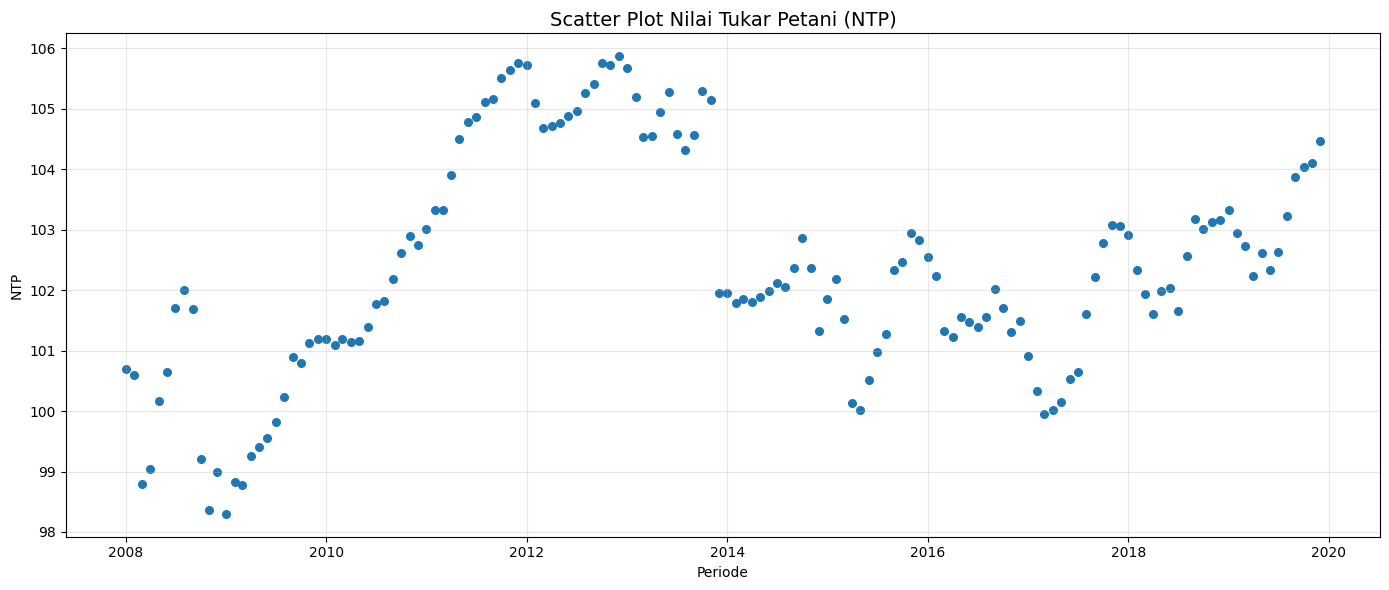

In [ ]:
# ============================================
# SCATTERPLOT
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.scatter(
    df['Periode'],
    df['NTP'],
    s=30
)

plt.title('Scatter Plot Nilai Tukar Petani (NTP)', fontsize=14)
plt.xlabel('Periode')
plt.ylabel('NTP')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

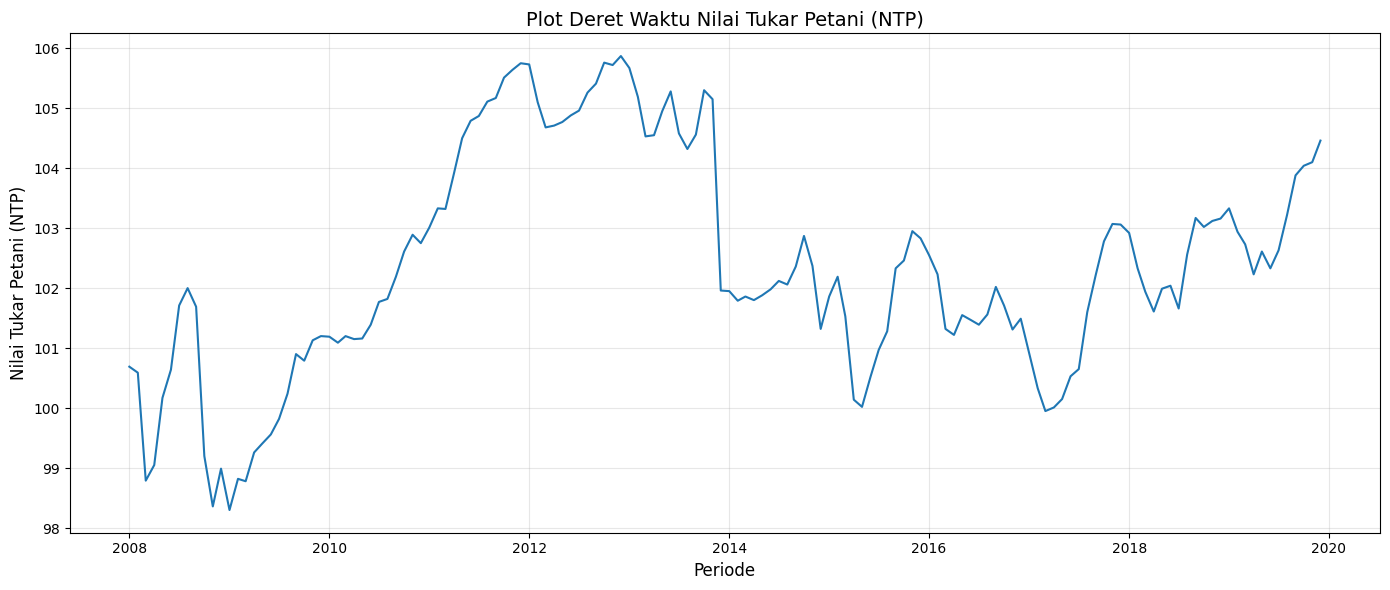

In [ ]:
# ============================================
# PLOT DERET WAKTU NTP
# ============================================
plt.figure(figsize=(14, 6))

plt.plot(
    df['Periode'],
    df['NTP'],
    linewidth=1.5
)

plt.title('Plot Deret Waktu Nilai Tukar Petani (NTP)', fontsize=14)
plt.xlabel('Periode', fontsize=12)
plt.ylabel('Nilai Tukar Petani (NTP)', fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Berdasarkan plot deret waktu NTP periode Januari 2008 sampai Desember 2019, terlihat bahwa nilai NTP mengalami fluktuasi dan perubahan level sepanjang periode pengamatan.
*   **Periode 2008 - 2009:** NTP berfluktuasi cukup besar. Nilai NTP sempat turun dari sekitar 100,7 hingga sekitar 98,3, kemudian kembali meningkat hingga sekitar 102 sebelum mengalami penurunan kembali.
*   **Periode 2010 - 2013:** NTP menunjukkan kecenderungan meningkat. Nilai NTP naik dari sekitar 101 hingga mencapai sekitar 105-106, dengan nilai tertinggi berada sekitar tahun 2012-2013.
*   **Periode 2014:** Terjadi perubahan level yang cukup tajam, yaitu penurunan NTP dari sekitar 105 menjadi sekitar 102.
*  **Periode 2014 - 2017:** NTP berfluktuasi pada kisaran 100-103, dengan beberapa periode mengalami penurunan dan kenaikan. Nilai terendah pada periode ini terlihat sekitar tahun 2015 dan 2017.
*   **Periode 2018 - 2019:** NTP kembali menunjukkan kecenderungan meningkat meskipun masih terdapat fluktuasi. Pada akhir 2019, NTP mencapai sekitar 104,46.

Perubahan level dan pola pergerakan pada plot tersebut mengindikasikan bahwa data NTP belum stasioner dalam rataan.

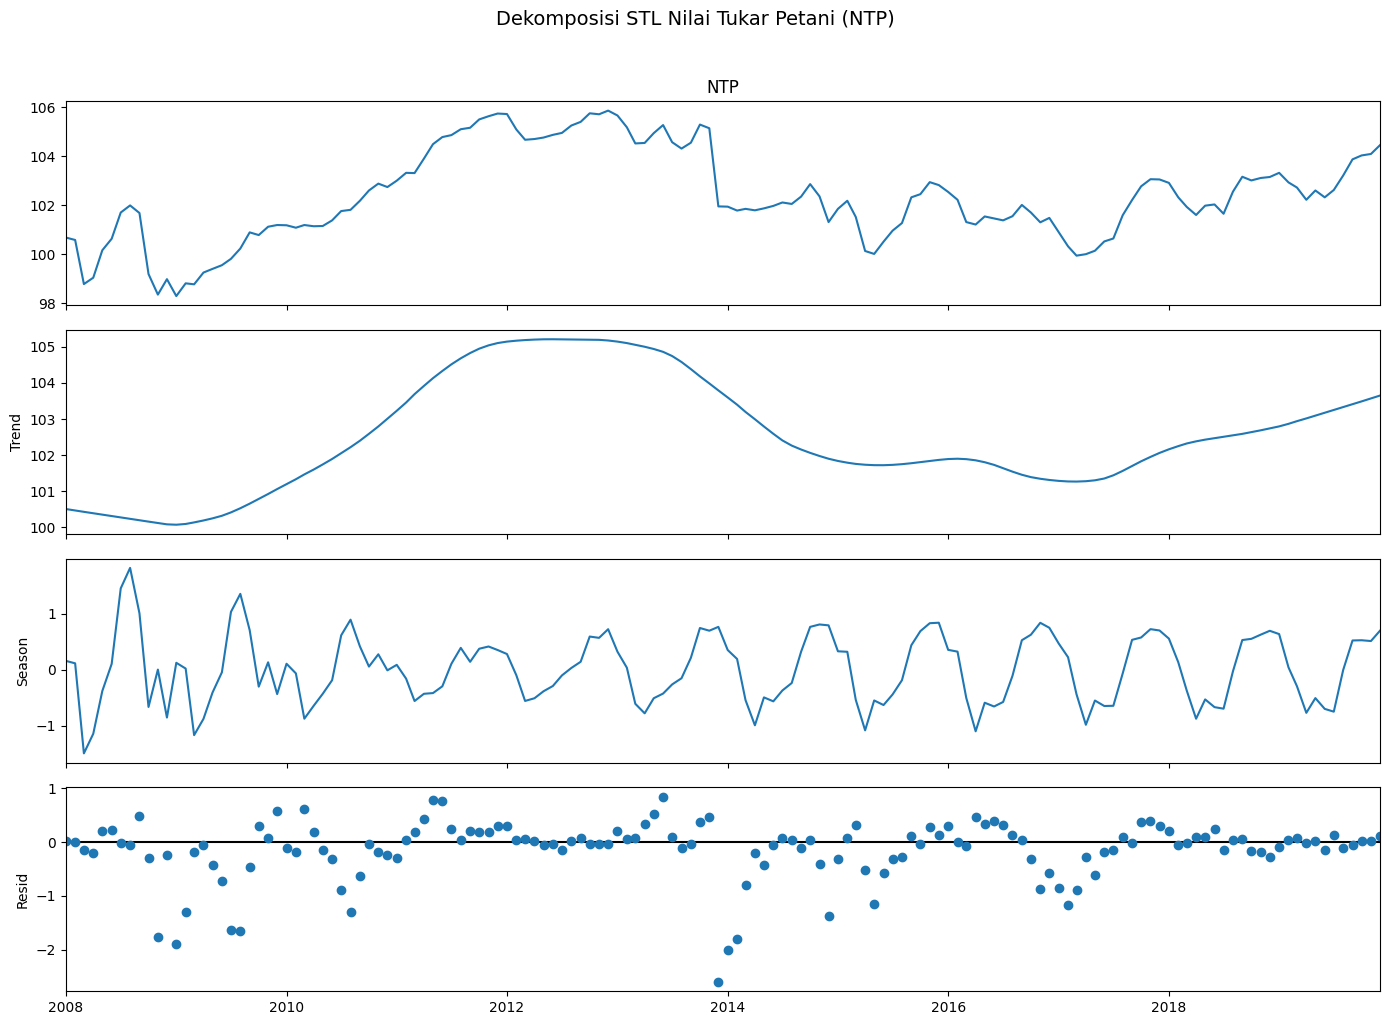

In [ ]:
# ============================================
# DEKOMPOSISI DERET WAKTU NTP - METODE STL
# ============================================

from statsmodels.tsa.seasonal import STL

# Dekomposisi STL dengan periode musiman 12 bulan
stl = STL(df.set_index('Periode')['NTP'], period=12, robust=True)
result = stl.fit()

# Plot dekomposisi
fig = result.plot()
fig.set_size_inches(14, 10)

fig.suptitle(
    'Dekomposisi STL Nilai Tukar Petani (NTP)',
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()

Berdasarkan hasil dekomposisi STL, data NTP terdiri atas komponen trend, seasonal, dan residual yang menunjukkan karakteristik berbeda.
*   **Komponen trend** memperlihatkan perubahan pola sepanjang periode pengamatan, yaitu peningkatan pada sekitar 2009 - 2013, penurunan pada 2013 - 2015, relatif stabil pada 2015 - 2017, kemudian kembali meningkat pada 2017 - 2019. Perubahan pola tersebut menunjukkan adanya perubahan tingkat rata-rata NTP sepanjang waktu.
*   **Komponen seasonal** menunjukkan pola yang berulang secara relatif teratur, terutama pada periode setelah tahun 2014, yang mengindikasikan adanya pola musiman tahunan pada data NTP bulanan.
*   **Komponen residual** sebagian besar berfluktuasi di sekitar nilai nol, meskipun terdapat beberapa penyimpangan yang cukup besar pada periode tertentu.   

Secara keseluruhan, hasil dekomposisi STL menunjukkan bahwa data NTP memiliki komponen trend dan seasonal yang perlu diperhatikan dalam pemodelan deret waktu.

# **CEK KESTASIONERAN**

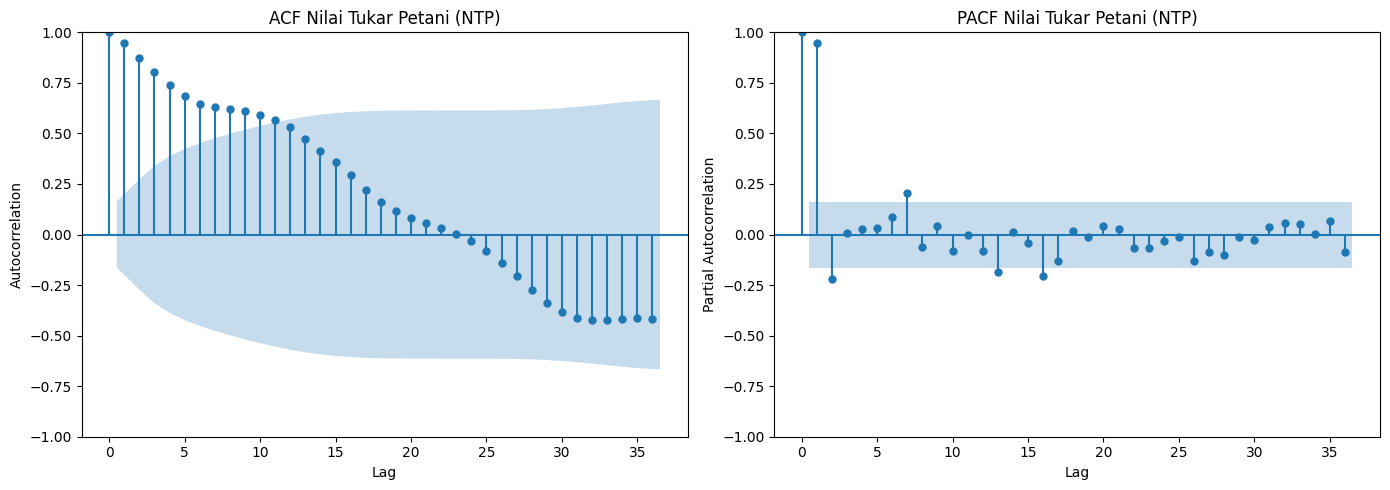

In [ ]:
# ============================================
# ACF & PACF PLOT
# ============================================

# Mengambil variabel NTP
y = df['NTP']

# Plot ACF dan PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF
plot_acf(
    y,
    lags=36,
    ax=axes[0]
)
axes[0].set_title('ACF Nilai Tukar Petani (NTP)')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')

# PACF
plot_pacf(
    y,
    lags=36,
    ax=axes[1],
    method='ywm'
)
axes[1].set_title('PACF Nilai Tukar Petani (NTP)')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

Berdasarkan **plot ACF** data NTP, terlihat bahwa autokorelasi pada lag awal sangat tinggi, dengan nilai ACF pada lag 1 sekitar 0,94, kemudian menurun secara perlahan hingga mendekati nol pada sekitar lag 22 - 23. Pola penurunan ACF yang lambat menunjukkan adanya ketergantungan temporal yang kuat dan memberikan indikasi bahwa data NTP belum stasioner. Sementara itu, **plot PACF** menunjukkan spike yang sangat tinggi pada lag 1 dan beberapa spike pada lag lainnya yang berada di luar batas interval kepercayaan. Hasil ACF dan PACF tersebut mengindikasikan bahwa data NTP belum stasioner. Oleh karena itu, diperlukan uji Augmented Dickey-Fuller (ADF) untuk menguji secara statistik kestasioneran data NTP.

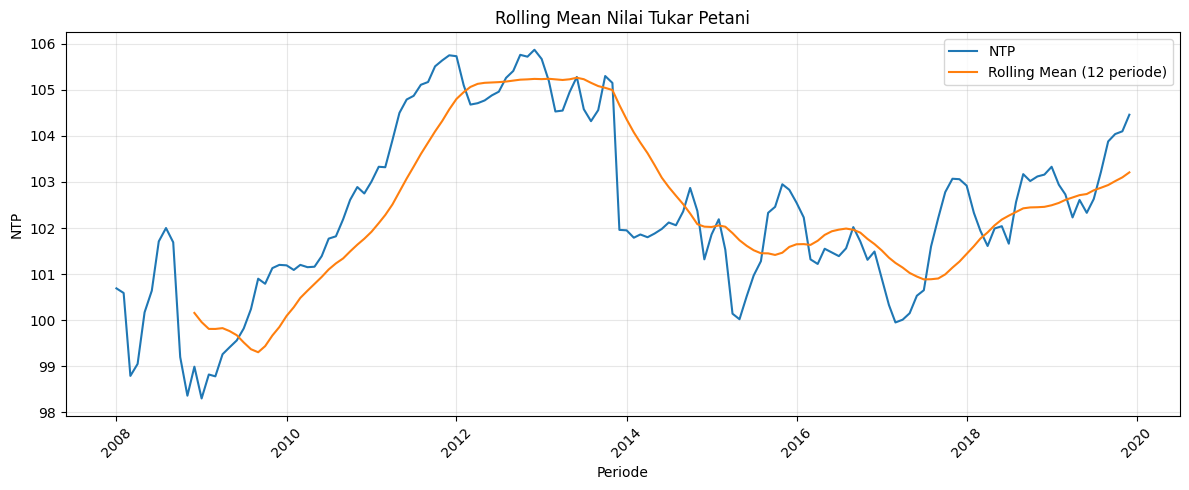

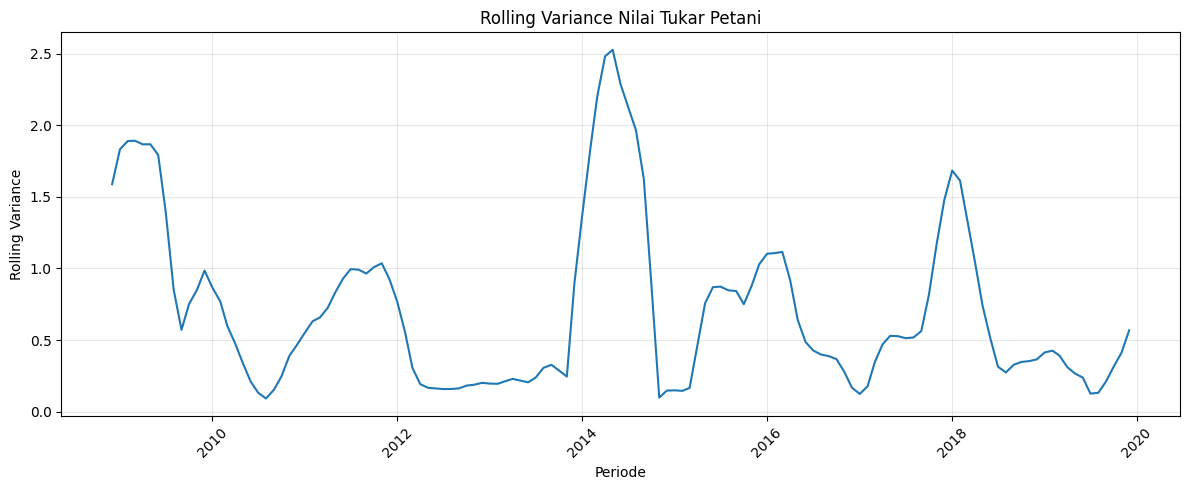

In [ ]:
# ============================================================
# MELIHAT KETIDAKSTASIONERAN DALAM RATAAN DAN RAGAM
# ============================================================


# MEMASTIKAN STRUKTUR DATA
# Jika Periode masih menjadi index, kembalikan menjadi kolom
if 'Periode' not in df.columns:
    df = df.reset_index()

# Pastikan Periode bertipe datetime
df['Periode'] = pd.to_datetime(df['Periode'])

# Urutkan berdasarkan periode
df = df.sort_values('Periode').reset_index(drop=True)

#====================================================
window = 12

rolling_mean = df['NTP'].rolling(window=window).mean()
rolling_var = df['NTP'].rolling(window=window).var()

# ============================================
# ROLLING MEAN
# ============================================

plt.figure(figsize=(12, 5))

plt.plot(
    df['Periode'],
    df['NTP'],
    label='NTP'
)

plt.plot(
    df['Periode'],
    rolling_mean,
    label='Rolling Mean (12 periode)'
)

plt.xlabel('Periode')
plt.ylabel('NTP')
plt.title('Rolling Mean Nilai Tukar Petani')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================
# ROLLING VARIANCE
# ============================================

plt.figure(figsize=(12, 5))

plt.plot(
    df['Periode'],
    rolling_var
)

plt.xlabel('Periode')
plt.ylabel('Rolling Variance')
plt.title('Rolling Variance Nilai Tukar Petani')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Berdasarkan grafik rolling mean dan rolling variance dengan jendela 12 periode (12 bulan), terlihat bahwa nilai rataan dan ragam NTP mengalami perubahan sepanjang periode pengamatan.
* Rolling mean menunjukkan pola yang tidak konstan, yaitu meningkat pada sekitar 2009 - 2012 hingga mencapai sekitar 105, kemudian menurun hingga sekitar 101 pada periode 2015 - 2017, dan kembali meningkat hingga sekitar 103 pada akhir 2019. Perubahan nilai rolling mean tersebut mengindikasikan bahwa rataan NTP berubah dari waktu ke waktu, sehingga memberikan indikasi adanya ketidakstasioneran dalam rataan.
* Rolling variance menunjukkan fluktuasi yang cukup besar, dengan peningkatan varians yang terlihat sekitar 2008 - 2009, 2014, dan 2018, serta nilai yang relatif lebih rendah pada beberapa periode lainnya. Hal tersebut menunjukkan bahwa tingkat variabilitas NTP juga berubah sepanjang waktu dan memberikan indikasi bahwa ragam belum sepenuhnya konstan.

Dengan demikian, berdasarkan pemeriksaan secara visual terhadap rolling mean dan rolling variance, data NTP menunjukkan indikasi ketidakstasioneran dalam rataan dan ketidakstabilan ragam. Selanjutnya, ketidakstasioneran dalam rataan dikonfirmasi menggunakan uji ADF, sedangkan kestabilan ragam ditangani melalui transformasi yang sesuai dan diperiksa lebih lanjut menggunakan uji ARCH-LM.

In [ ]:
# ============================================================
# UJI STASIONERITAS MENGGUNAKAN ADF (Augmented Dickey-Fuller)
# ============================================================

from statsmodels.tsa.stattools import adfuller

# Uji ADF
adf_test = adfuller(y, result_object=True)

print("ADF Statistic :", adf_test.statistic)
print("p-value       :", adf_test.pvalue)

print("Critical Values:")
for key, value in adf_test.critical_values.items():
    print(f"   {key}: {value}")

# Keputusan
if adf_test.pvalue < 0.05:
    print("\nKeputusan: Tolak H0")
    print("Data stasioner.")
else:
    print("\nKeputusan: Gagal menolak H0")
    print("Data tidak stasioner.")

ADF Statistic : -1.3078269500464923
p-value       : 0.6255839102511558
Critical Values:
   1%: -3.479007355368944
   5%: -2.8828782366015093
   10%: -2.5781488587564603

Keputusan: Gagal menolak H0
Data tidak stasioner.


---
Hipotesis Uji Augmented Dickey-Fuller (ADF):
*   $H_0$ menyatakan deret tidak stasioner
*   $H_1$ menyatakan deret stasioner

Kriteria keputusan: Tolak $H_0$ jika p-value < 0.05
  
---

Berdasarkan hasil uji *Augmented Dickey-Fuller* (ADF), diperoleh nilai statistik ADF sebesar -1,3078 dengan *p-value* sebesar 0,6256. Pada taraf signifikansi 5%, nilai *p-value* lebih besar dari 0,05 sehingga **gagal menolak $H_0$**. Dengan demikian, dapat disimpulkan bahwa data NTP dapat dinyatakan belum stasioner, sehingga diperlukan penanganan terhadap ketidakstasioneran sebelum dilakukan pemodelan deret waktu.

In [ ]:
# ============================================================
# UJI STASIONERITAS DALAM RAGAM MENGGUNAKAN UJI ARCH-LM
# ============================================================

from statsmodels.tsa.stattools import adfuller

# Data NTP
y = df['NTP'].dropna()

# Uji ARCH-LM
arch_test = het_arch(y, nlags=12)

print("===== UJI ARCH-LM =====")
print("LM Statistic :", arch_test[0])
print("LM p-value   :", arch_test[1])
print("F Statistic  :", arch_test[2])
print("F p-value    :", arch_test[3])

# Keputusan
if arch_test[1] < 0.05:
    print("\nKeputusan: Tolak H0")
    print("Terdapat efek ARCH (ragam tidak konstan).")
else:
    print("\nKeputusan: Gagal menolak H0")
    print("Tidak terdapat efek ARCH.")

===== UJI ARCH-LM =====
LM Statistic : 123.74861131972857
LM p-value   : 1.1031855787820413e-20
F Statistic  : 148.7232969469415
F p-value    : 1.3216060147988868e-65

Keputusan: Tolak H0
Terdapat efek ARCH (ragam tidak konstan).


---
Hipotesis Uji ARCH-LM:
*   $H_0$ menyatakan tidak terdapat efek ARCH
*   $H_1$ menyatakan terdapat efek ARCH

Kriteria keputusan: Tolak $H_0$ jika p-value < 0.05
  
---

Berdasarkan hasil uji ARCH-LM pada data NTP, diperoleh nilai LM Statistic sebesar 123,7486 dengan *p-value* sebesar 1,1032 × 10⁻²⁰, sedangkan F Statistic sebesar 148,7233 dengan *p-value* sebesar 1,3216 × 10⁻⁶⁵. Pada taraf signifikansi 5%, kedua nilai *p-value* tersebut lebih kecil dari 0,05 sehingga **tolak $H_0$**. Dengan demikian, terdapat efek ARCH pada data NTP, yang menunjukkan adanya ketidakstabilan ragam bersyarat (*conditional variance*) atau perubahan volatilitas yang bergantung pada informasi masa lalu. Hasil tersebut mengindikasikan bahwa ragam data NTP belum stabil, sehingga diperlukan penanganan terhadap ketidakstabilan ragam, salah satunya melalui **transformasi Box-Cox** sebelum dilakukan tahap differencing dan pemodelan deret waktu.

# **TRANSFORMASI BOX-COX → DIFFERENCING**

## **TRANSFORMASI BOX-COX**

Nilai lambda optimal: -1.1625


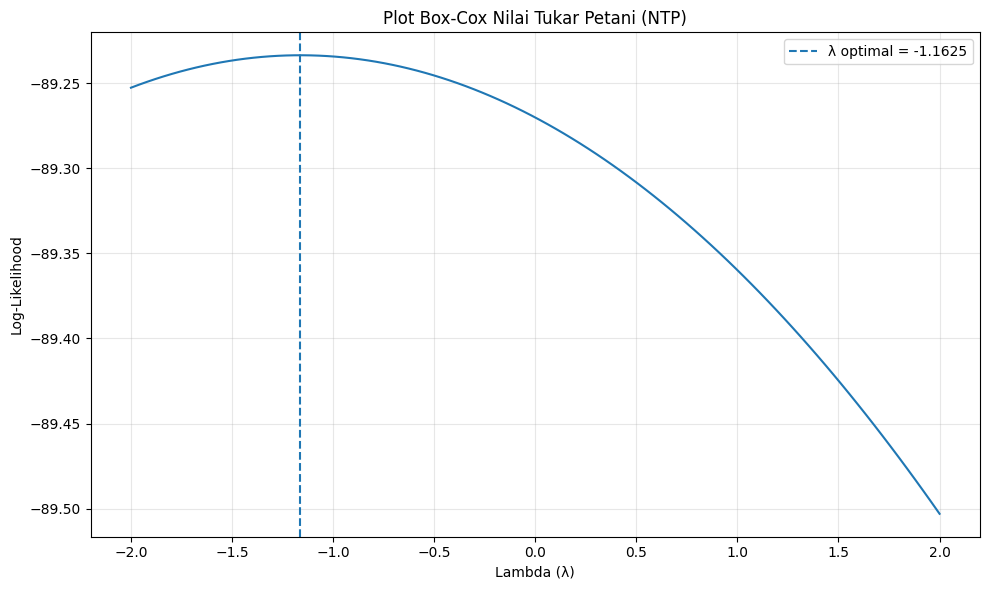

In [ ]:
# ============================================================
# TRANSFORMASI BOX-COX
# ============================================================

from scipy.stats import boxcox
import numpy as np
import matplotlib.pyplot as plt

# Transformasi Box-Cox
y = df['NTP'].dropna()
y_boxcox, lambda_opt = boxcox(y)

print(f"Nilai lambda optimal: {lambda_opt:.4f}")

# Menyimpan hasil transformasi Box-Cox ke dataframe
df['NTP_BoxCox'] = np.nan
df.loc[y.index, 'NTP_BoxCox'] = y_boxcox

# Mencari range lambda untuk plot
lambdas = np.linspace(-2, 2, 100)
log_likelihood = []

n = len(y)

for lam in lambdas:
    if lam == 0:
        transformed = np.log(y)
    else:
        transformed = (y**lam - 1) / lam

    # log-likelihood Box-Cox
    variance = np.var(transformed, ddof=1)
    ll = -n/2 * np.log(variance) + (lam - 1) * np.sum(np.log(y))
    log_likelihood.append(ll)

# Plot Box-Cox
plt.figure(figsize=(10, 6))

plt.plot(lambdas, log_likelihood, linewidth=1.5)
plt.axvline(
    lambda_opt,
    linestyle='--',
    label=f'λ optimal = {lambda_opt:.4f}'
)

plt.xlabel('Lambda (λ)')
plt.ylabel('Log-Likelihood')
plt.title('Plot Box-Cox Nilai Tukar Petani (NTP)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Berdasarkan hasil transformasi Box-Cox, diperoleh nilai ${\lambda}$ optimal sebesar -1,1625, yang ditunjukkan oleh titik maksimum pada kurva log-likelihood. Nilai ${\lambda}$ negatif menunjukkan bahwa transformasi yang sesuai untuk data NTP merupakan transformasi pangkat dengan eksponen negatif. Dengan demikian, data NTP ditransformasikan menggunakan ${\lambda} = -1,1625$ untuk membantu menstabilkan ragam data sebelum dilakukan tahap differencing dan pemodelan deret waktu.

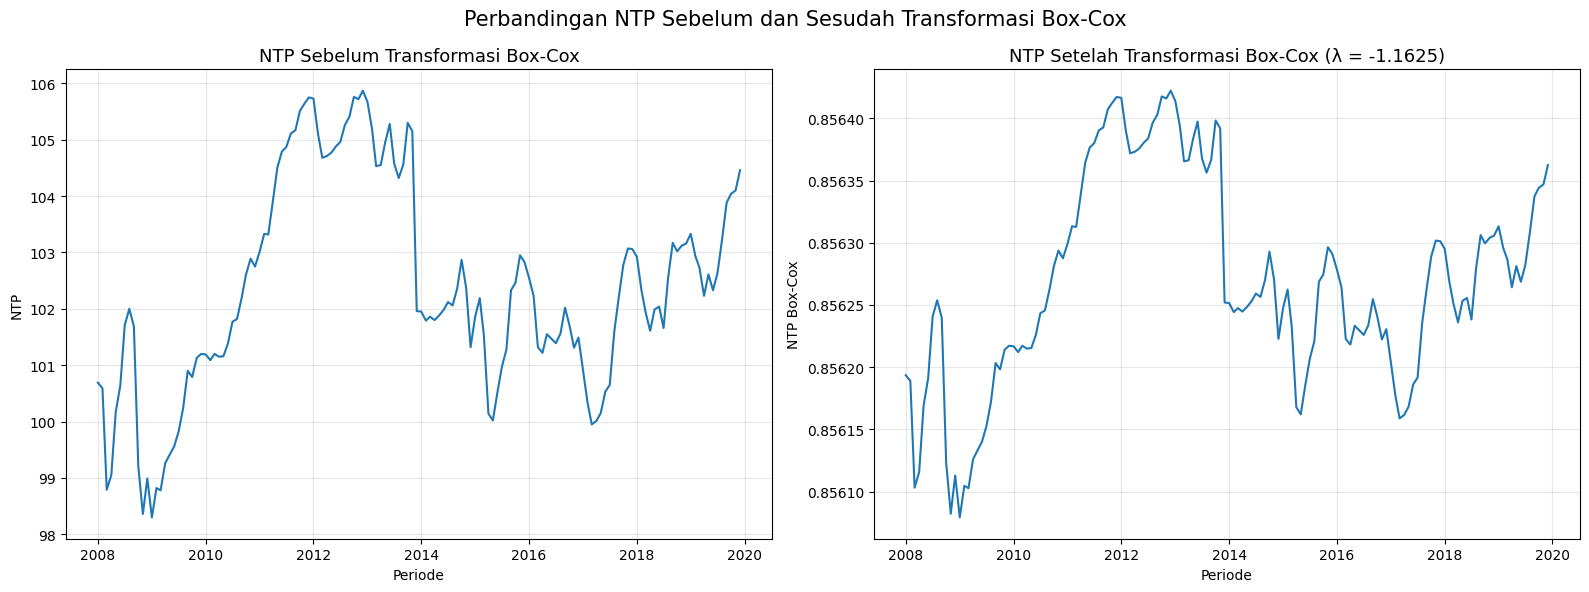

In [ ]:
# ===========================================================================
# Perbandingan Plot Deret Waktu NTP Sebelum dan Sesudah Transformasi Box-Cox
# ===========================================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------
# Plot 1: NTP sebelum transformasi Box-Cox
# ------------------------------------------
ax[0].plot(
    df['Periode'],
    df['NTP'],
    linewidth=1.5
)

ax[0].set_title(
    'NTP Sebelum Transformasi Box-Cox',
    fontsize=13
)

ax[0].set_xlabel('Periode')
ax[0].set_ylabel('NTP')
ax[0].grid(True, alpha=0.3)


# ------------------------------------------
# Plot 2: NTP sesudah transformasi Box-Cox
# ------------------------------------------
ax[1].plot(
    df['Periode'],
    df['NTP_BoxCox'],
    linewidth=1.5
)

ax[1].set_title(
    f'NTP Setelah Transformasi Box-Cox (λ = {lambda_opt:.4f})',
    fontsize=13
)

ax[1].set_xlabel('Periode')
ax[1].set_ylabel('NTP Box-Cox')
ax[1].grid(True, alpha=0.3)


# ------------------------------------------
# Judul utama
# ------------------------------------------
fig.suptitle(
    'Perbandingan NTP Sebelum dan Sesudah Transformasi Box-Cox',
    fontsize=15
)

plt.tight_layout()
plt.show()

Berdasarkan grafik perbandingan NTP sebelum dan sesudah transformasi Box-Cox dengan ${\lambda} = -1,1625$, terlihat bahwa pola pergerakan data setelah transformasi masih mengikuti pola umum data sebelum transformasi. Pada data sebelum transformasi, NTP berfluktuasi pada kisaran sekitar 98 - 106 dan menunjukkan perubahan yang cukup jelas sepanjang periode pengamatan.  

Setelah transformasi Box-Cox, pola naik-turun tersebut tetap terlihat pada periode yang sama, tetapi skala nilai berubah secara signifikan, yaitu menjadi sekitar 0,85605 - 0,85640. Perubahan skala tersebut merupakan hasil dari penerapan transformasi pangkat dengan ${\lambda}$ negatif. Transformasi Box-Cox digunakan untuk membantu menstabilkan ragam, bukan untuk menghilangkan trend atau langsung menghasilkan data yang stasioner dalam rataan.

Oleh karena itu, setelah transformasi Box-Cox, perlu dilakukan pemeriksaan kembali terhadap kestasioneran rataan menggunakan uji ADF dan terhadap efek ARCH menggunakan uji ARCH-LM. Jika hasil ADF masih menunjukkan ketidakstasioneran, maka dapat dilanjutkan dengan first differencing.

In [ ]:
# ============================================================
# UJI ADF SETELAH TRANSFORMASI BOX-COX
# ============================================================

from statsmodels.tsa.stattools import adfuller

# Data setelah transformasi Box-Cox
y_boxcox = df['NTP_BoxCox'].dropna()

# Uji Augmented Dickey-Fuller (ADF)
adf_result = adfuller(y_boxcox, result_object=False)

# Menampilkan hasil
print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}% : {value}")

# Keputusan pengujian
alpha = 0.05

if adf_result[1] < alpha:
    print("\nKeputusan: Tolak H0")
    print("Kesimpulan: Data setelah transformasi Box-Cox sudah stasioner dalam rataan.")
else:
    print("\nKeputusan: Gagal menolak H0")
    print("Kesimpulan: Data setelah transformasi Box-Cox belum stasioner dalam rataan.")

ADF Statistic : -1.3013113534787792
p-value       : 0.6285721545137264

Critical Values:
1%% : -3.479007355368944
5%% : -2.8828782366015093
10%% : -2.5781488587564603

Keputusan: Gagal menolak H0
Kesimpulan: Data setelah transformasi Box-Cox belum stasioner dalam rataan.


Berdasarkan hasil uji *Augmented Dickey-Fuller* (ADF) setelah transformasi Box-Cox, diperoleh nilai statistik ADF sebesar -1,3013 dengan *p-value* sebesar 0,6286. Pada taraf signifikansi 5%, nilai *p-value* lebih besar dari 0,05 sehingga **gagal menolak $H_0$**. Dengan demikian, dapat disimpulkan bahwa data NTP setelah transformasi Box-Cox dapat dinyatakan masih belum stasioner dalam rataan. Transformasi Box-Cox belum menghilangkan ketidakstasioneran dalam rataan, sehingga tahap selanjutnya adalah melakukan first differencing terhadap data hasil transformasi Box-Cox.

In [ ]:
# ============================================================
# UJI ARCH-LM SETELAH TRANSFORMASI BOX-COX
# ============================================================

from statsmodels.stats.diagnostic import het_arch
import warnings

# Menghilangkan FutureWarning dari statsmodels
warnings.filterwarnings("ignore", category=FutureWarning)

# Data setelah transformasi Box-Cox
y_boxcox = df['NTP_BoxCox'].dropna()

# Uji ARCH-LM
arch_result = het_arch(y_boxcox, nlags=12)

# Menampilkan hasil
print("LM Statistic :", arch_result[0])
print("LM p-value   :", arch_result[1])
print("F Statistic  :", arch_result[2])
print("F p-value    :", arch_result[3])

# Keputusan pengujian
alpha = 0.05

if arch_result[1] < alpha:
    print("\nKeputusan: Tolak H0")
    print("Kesimpulan: Terdapat efek ARCH pada data setelah transformasi Box-Cox.")
else:
    print("\nKeputusan: Gagal menolak H0")
    print("Kesimpulan: Tidak terdapat efek ARCH pada data setelah transformasi Box-Cox.")

LM Statistic : 123.71280350421459
LM p-value   : 1.1215183131069234e-20
F Statistic  : 148.03783588020949
F p-value    : 1.707575393713454e-65

Keputusan: Tolak H0
Kesimpulan: Terdapat efek ARCH pada data setelah transformasi Box-Cox.


Berdasarkan hasil uji ARCH-LM pada data NTP setelah transformasi Box-Cox, diperoleh nilai LM Statistic sebesar 123,7128 dengan *p-value* sebesar 1,1215 × 10⁻²⁰, sedangkan F Statistic sebesar 148,0378 dengan *p-value* sebesar 1,7076 × 10⁻⁶⁵. Pada taraf signifikansi 5%, kedua nilai *p-value* tersebut lebih kecil dari 0,05 sehingga **tolak $H_0$**. Dengan demikian, masih terdapat efek ARCH pada data NTP setelah transformasi Box-Cox. Hasil ini menunjukkan adanya heteroskedastisitas bersyarat, yaitu perubahan variabilitas data yang masih berkaitan dengan informasi atau residual pada periode sebelumnya.

Dengan kata lain, transformasi Box-Cox dengan ${\lambda} = -1,1625$ belum menghilangkan efek ARCH pada data NTP. Karena hasil uji ADF juga menunjukkan data masih belum stasioner dalam rataan, tahap selanjutnya dapat dilakukan first differencing terhadap data hasil transformasi Box-Cox, kemudian uji ADF dan ARCH-LM dilakukan kembali pada data hasil differencing.

## **DIFFERENCING SETELAH TRANSFORMASI BOX-COX**

In [ ]:
# ============================================================
# FIRST DIFFERENCING SETELAH TRANSFORMASI BOX-COX
# ============================================================

# Differencing orde pertama
df['NTP_BoxCox_Diff'] = df['NTP_BoxCox'].diff()

# Menghilangkan NA pada observasi pertama
y_diff = df['NTP_BoxCox_Diff'].dropna()

# Menampilkan hasil
print(df[['Periode', 'NTP_BoxCox', 'NTP_BoxCox_Diff']].head(10))

     Periode  NTP_BoxCox  NTP_BoxCox_Diff
0 2008-01-01    0.856194              NaN
1 2008-02-01    0.856189        -0.000005
2 2008-03-01    0.856103        -0.000086
3 2008-04-01    0.856116         0.000013
4 2008-05-01    0.856169         0.000053
5 2008-06-01    0.856191         0.000022
6 2008-07-01    0.856241         0.000049
7 2008-08-01    0.856254         0.000013
8 2008-09-01    0.856240        -0.000014
9 2008-10-01    0.856123        -0.000117


Berdasarkan hasil *first differencing* setelah transformasi Box-Cox, diperoleh data perubahan nilai NTP yang telah ditransformasikan. Nilai NTP_BoxCox_Diff menunjukkan perubahan antarperiode, dengan nilai positif menunjukkan peningkatan dan nilai negatif menunjukkan penurunan dibandingkan periode sebelumnya.
Pada beberapa periode awal, perubahan yang dihasilkan relatif kecil, seperti sebesar -0,000005 pada Februari 2008, -0,000086 pada Maret 2008, dan 0,000013 pada April 2008. Observasi pertama menghasilkan nilai **NaN** karena tidak tersedia nilai periode sebelumnya, sehingga jumlah observasi berkurang satu dari 144 menjadi 143. Hasil ini merupakan data akhir dari proses transformasi Box-Cox → *First Differencing* yang selanjutnya digunakan untuk pengujian stasioneritas menggunakan ADF dan pengujian efek ARCH-LM serta identifikasi model melalui ACF dan PACF.

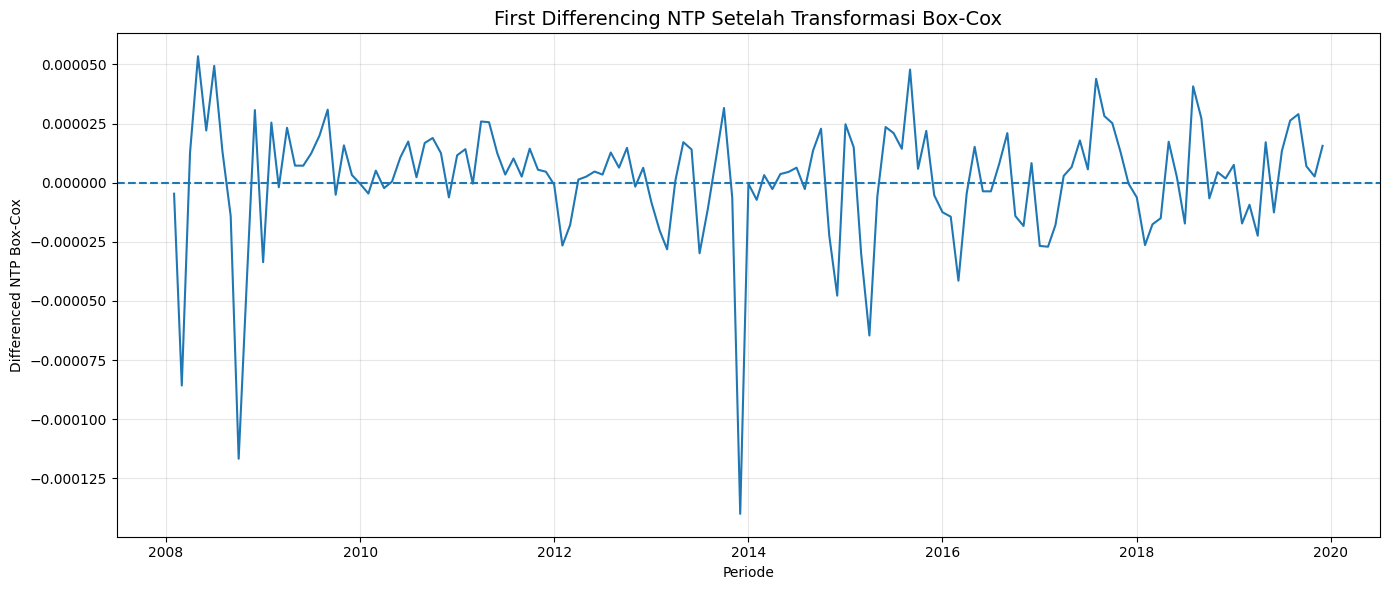

In [ ]:
# plot hasil differencing
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    df['Periode'].iloc[1:],
    y_diff,
    linewidth=1.5
)

plt.axhline(0, linestyle='--')

plt.title(
    'First Differencing NTP Setelah Transformasi Box-Cox',
    fontsize=14
)

plt.xlabel('Periode')
plt.ylabel('Differenced NTP Box-Cox')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Berdasarkan grafik *first differencing* data NTP setelah transformasi Box-Cox, terlihat bahwa nilai hasil differencing berfluktuasi di sekitar garis nol sepanjang periode pengamatan. Tidak terlihat adanya pola trend yang meningkat atau menurun secara konsisten, dan fluktuasi cenderung berada pada kisaran yang relatif kecil. Kondisi ini memberikan indikasi secara visual bahwa data sudah lebih stabil dalam rataan setelah dilakukan *first differencing*. Namun, kestasioneran tidak dapat ditentukan hanya berdasarkan grafik, sehingga perlu dikonfirmasi menggunakan uji ADF pada data hasil differencing.

In [ ]:
# ============================================================
# UJI ADF SETELAH TRANSFORMASI BOX-COX & FIRST DIFFERENCING
# ============================================================

from statsmodels.tsa.stattools import adfuller

# Uji ADF pada data hasil Box-Cox dan first differencing
adf_diff = adfuller(y_diff, result_object=False)

print("ADF Statistic :", adf_diff[0])
print("p-value       :", adf_diff[1])

print("\nCritical Values:")
for key, value in adf_diff[4].items():
    print(f"{key}% : {value}")

# Keputusan pengujian
alpha = 0.05

if adf_diff[1] < alpha:
    print("\nKeputusan: Tolak H0")
    print("Kesimpulan: Data sudah stasioner dalam rataan.")
else:
    print("\nKeputusan: Gagal menolak H0")
    print("Kesimpulan: Data masih belum stasioner dalam rataan.")

ADF Statistic : -6.705737979918733
p-value       : 3.789349744848224e-09

Critical Values:
1%% : -3.479007355368944
5%% : -2.8828782366015093
10%% : -2.5781488587564603

Keputusan: Tolak H0
Kesimpulan: Data sudah stasioner dalam rataan.


Berdasarkan hasil uji *Augmented Dickey-Fuller* (ADF) setelah transformasi Box-Cox dan *first differencing*, diperoleh nilai statistik ADF sebesar -6,7057 dengan *p-value* sebesar sebesar 3,7893 × 10⁻⁹. Pada taraf signifikansi 5%, nilai *p-value* lebih kecil dari 0,05 sehingga **Tolak $H_0$**. Dengan demikian, dapat disimpulkan bahwa data NTP setelah transformasi Box-Cox dan *first differencing* telah **stasioner dalam rataan**.

In [ ]:
# ============================================================
# UJI ARCH-LM SETELAH BOX-COX & FIRST DIFFERENCING
# ============================================================

from statsmodels.stats.diagnostic import het_arch
import warnings

# Data setelah Box-Cox dan first differencing
y_final = y_diff.dropna()

# Uji ARCH-LM
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    arch_diff = het_arch(y_final, nlags=12)

print("LM Statistic :", arch_diff[0])
print("LM p-value   :", arch_diff[1])
print("F Statistic  :", arch_diff[2])
print("F p-value    :", arch_diff[3])

# Keputusan pengujian
alpha = 0.05

if arch_diff[1] < alpha:
    print("\nKeputusan: Tolak H0")
    print("Kesimpulan: Terdapat efek ARCH pada data.")
else:
    print("\nKeputusan: Gagal menolak H0")
    print("Kesimpulan: Tidak terdapat efek ARCH pada data.")

LM Statistic : 0.9942994442415538
LM p-value   : 0.9999862795286895
F Statistic  : 0.07520653191805148
F p-value    : 0.9999901681697434

Keputusan: Gagal menolak H0
Kesimpulan: Tidak terdapat efek ARCH pada data.


Berdasarkan hasil uji ARCH-LM setelah transformasi Box-Cox dan *first differencing*, diperoleh *p-value* LM sebesar 0,99999 dan *p-value* F sebesar 0,99999. Pada taraf signifikansi 5%, kedua p-value lebih besar dari 0,05 sehingga gagal menolak $H_0$. Dengan demikian, tidak terdapat bukti adanya efek ARCH pada data NTP setelah transformasi Box-Cox dan *first differencing*. Hal ini menunjukkan bahwa heteroskedastisitas bersyarat tidak terdeteksi pada data hasil transformasi dan differencing.

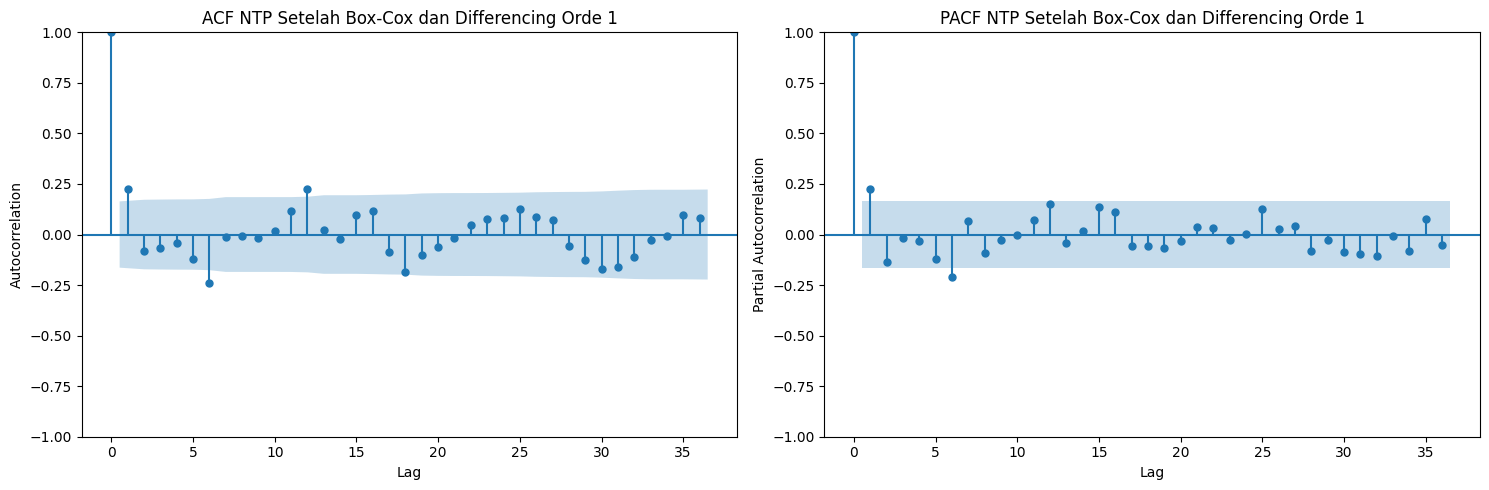

In [ ]:
# ============================================================
# ACF DAN PACF SETELAH BOX-COX DAN FIRST DIFFERENCING
# ============================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Membuat ACF dan PACF dalam satu frame
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# ------------------------------------------------------------
# ACF
# ------------------------------------------------------------
plot_acf(
    y_diff,
    lags=36,
    ax=ax[0]
)

ax[0].set_title(
    'ACF NTP Setelah Box-Cox dan Differencing Orde 1'
)

ax[0].set_xlabel('Lag')
ax[0].set_ylabel('Autocorrelation')


# ------------------------------------------------------------
# PACF
# ------------------------------------------------------------
plot_pacf(
    y_diff,
    lags=36,
    ax=ax[1],
    method='ywm'
)

ax[1].set_title(
    'PACF NTP Setelah Box-Cox dan Differencing Orde 1'
)

ax[1].set_xlabel('Lag')
ax[1].set_ylabel('Partial Autocorrelation')


# ------------------------------------------------------------
# Tampilan
# ------------------------------------------------------------
plt.tight_layout()
plt.show()

Berdasarkan plot ACF dan PACF data NTP setelah transformasi Box-Cox dan *first differencing*, terlihat bahwa sebagian besar nilai autokorelasi berada di dalam batas interval kepercayaan. Pada plot ACF, terdapat spike yang melewati batas pada lag 1, 6, 12, dan beberapa lag lainnya, dengan nilai ACF pada lag 1 sekitar 0,22. Sementara itu, plot PACF menunjukkan spike yang cukup jelas pada lag 1, 6, 12, dan 16. Spike pada lag 12 juga memberikan indikasi adanya pola musiman tahunan, karena data NTP merupakan data bulanan. Plot ACF dan PACF ini dapat digunakan sebagai dasar untuk menentukan kandidat orde AR, MA, serta komponen musiman pada tahap identifikasi model ARIMA.

---

# **DIFFERENCING → TRANSFORMASI BOX-COX**

## **FIRST DIFFERENCING**

In [ ]:
# ============================================================
# FIRST DIFFERENCING DATA NTP
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Pastikan data diurutkan berdasarkan periode
df = df.sort_values('Periode').reset_index(drop=True)

# First differencing
df['NTP_Diff'] = df['NTP'].diff()

# Menghilangkan NA pada observasi pertama
y_diff = df['NTP_Diff'].dropna()

# Menampilkan hasil
print("Hasil First Differencing:")
print(df[['Periode', 'NTP', 'NTP_Diff']].head(10))

print("\nJumlah data awal :", df['NTP'].notna().sum())
print("Jumlah data setelah differencing :", len(y_diff))

Hasil First Differencing:
     Periode     NTP  NTP_Diff
0 2008-01-01  100.69       NaN
1 2008-02-01  100.59     -0.10
2 2008-03-01   98.79     -1.80
3 2008-04-01   99.05      0.26
4 2008-05-01  100.17      1.12
5 2008-06-01  100.64      0.47
6 2008-07-01  101.71      1.07
7 2008-08-01  102.00      0.29
8 2008-09-01  101.69     -0.31
9 2008-10-01   99.20     -2.49

Jumlah data awal : 144
Jumlah data setelah differencing : 143


Hasil *first differencing* menunjukkan bahwa data NTP berubah dari nilai level menjadi perubahan NTP antarperiode. Nilai positif menunjukkan peningkatan NTP dibandingkan periode sebelumnya, sedangkan nilai negatif menunjukkan penurunan.  
Contoh:
* Februari 2008 terjadi penurunan sebesar 0,10   
* Maret 2008 mengalami penurunan sebesar 1,80
* April 2008 mengalami peningkatan sebesar 0,26
* Oktober 2008 mengalami penurunan yang relatif besar sebesar 2,49   

Setelah dilakukan *first differencing*, jumlah observasi berkurang dari 144 menjadi 143 observasi karena observasi pertama tidak memiliki nilai periode sebelumnya sehingga menghasilkan nilai **NaN**. Hasil *first differencing* ini selanjutnya digunakan untuk tahap transformasi Box-Cox.

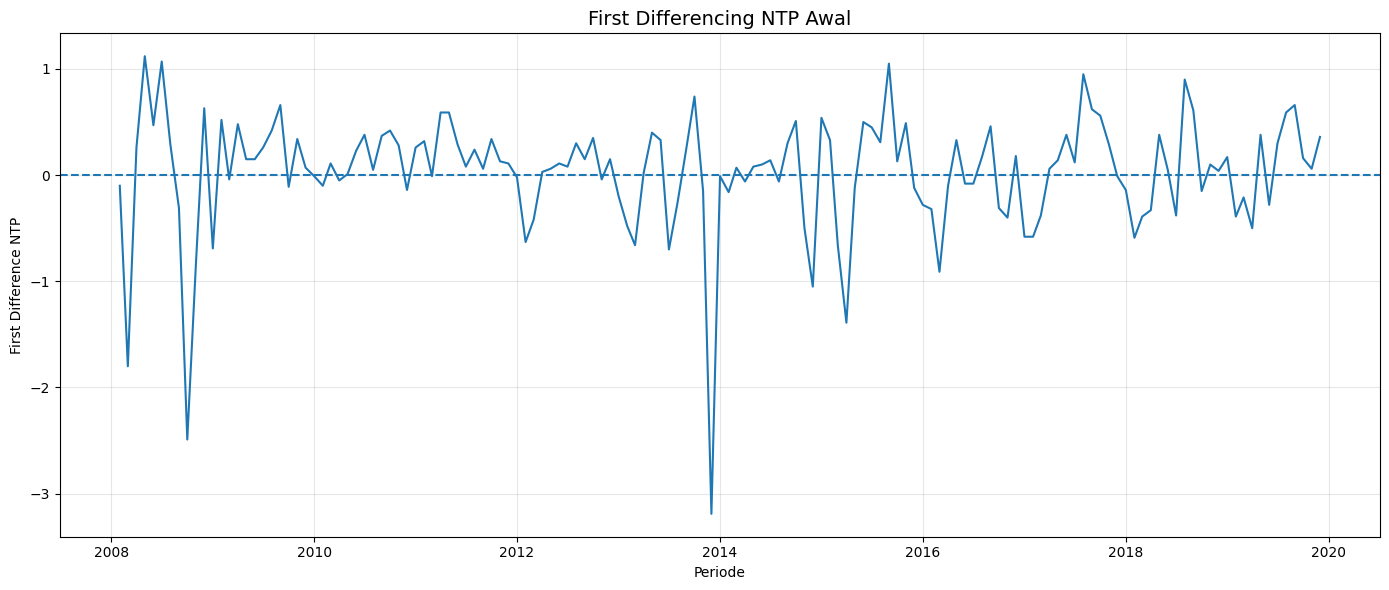

In [ ]:
# ============================================================
# PLOT FIRST DIFFERENCING
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    df['Periode'].iloc[1:],
    y_diff,
    linewidth=1.5
)

plt.axhline(0, linestyle='--')

plt.title(
    'First Differencing NTP Awal',
    fontsize=14
)

plt.xlabel('Periode')
plt.ylabel('First Difference NTP')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Berdasarkan grafik *first differencing* data NTP, terlihat bahwa nilai hasil differencing berfluktuasi di sekitar garis nol sepanjang periode pengamatan. Tidak terlihat adanya pola trend yang meningkat atau menurun secara konsisten setelah dilakukan *first differencing*. Sebagian besar nilai berada pada kisaran yang relatif stabil, meskipun terdapat beberapa fluktuasi ekstrem pada periode tertentu. Kondisi ini memberikan indikasi secara visual bahwa data menjadi lebih stabil dalam rataan setelah dilakukan *first differencing*. Namun, kestasioneran tidak dapat ditentukan hanya berdasarkan grafik, sehingga perlu dikonfirmasi menggunakan uji ADF pada data hasil *first differencing*.

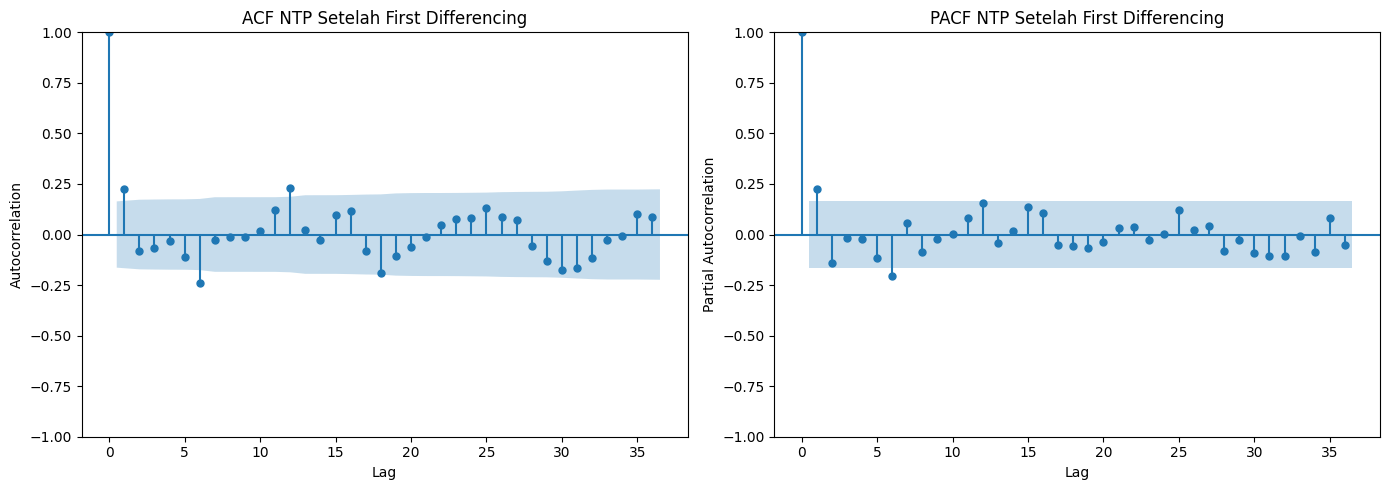

In [ ]:
# ============================================================
# ACF DAN PACF SETELAH FIRST DIFFERENCING
# ============================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Data hasil first differencing
y_diff = df['NTP_Diff'].dropna()

# Membuat ACF dan PACF dalam satu frame
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------
# Plot ACF - sebelah kiri
# ------------------------------------------------------------

plot_acf(
    y_diff,
    lags=36,
    alpha=0.05,
    ax=axes[0]
)

axes[0].set_title('ACF NTP Setelah First Differencing')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')

# ------------------------------------------------------------
# Plot PACF - sebelah kanan
# ------------------------------------------------------------

plot_pacf(
    y_diff,
    lags=36,
    alpha=0.05,
    method='ywm',
    ax=axes[1]
)

axes[1].set_title('PACF NTP Setelah First Differencing')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Partial Autocorrelation')

# Mengatur jarak antar plot
plt.tight_layout()

# Menampilkan
plt.show()

Berdasarkan **grafik ACF** data NTP setelah *first differencing*, terlihat bahwa sebagian besar nilai autokorelasi berada di dalam batas interval kepercayaan. Namun, terdapat beberapa lag yang berada di luar batas interval kepercayaan, yaitu pada lag 1, 6, 11, 12, dan 18. Kondisi tersebut menunjukkan bahwa masih terdapat autokorelasi pada beberapa lag setelah dilakukan *first differencing*. Pola ACF tidak menunjukkan penurunan yang tajam pada beberapa lag awal, sehingga struktur ketergantungan antarwaktu masih perlu dipertimbangkan dalam pemodelan. Kemudian **grafik PACF** data NTP setelah *first differencing*, sebagian besar nilai partial autocorrelation berada di dalam batas interval kepercayaan. Beberapa lag terlihat berada di luar batas tersebut, terutama pada lag 1, 6, dan 12. Hal ini menunjukkan adanya hubungan langsung antara nilai pada periode tertentu dengan beberapa periode sebelumnya setelah pengaruh lag lainnya diperhitungkan. Pola PACF tersebut dapat digunakan sebagai pertimbangan awal dalam menentukan orde model AR pada data yang telah didifferencing.

In [ ]:
# ============================================================
# UJI ADF SETELAH FIRST DIFFERENCING
# ============================================================

from statsmodels.tsa.stattools import adfuller

# Uji ADF
adf_diff = adfuller(y_diff, result_object=False)

print("ADF Statistic :", adf_diff[0])
print("p-value       :", adf_diff[1])

print("\nCritical Values:")
for key, value in adf_diff[4].items():
    print(f"{key}% : {value}")

# Keputusan pengujian
alpha = 0.05

if adf_diff[1] < alpha:
    print("\nKeputusan: Tolak H0")
    print("Kesimpulan: Data sudah stasioner dalam rataan.")
else:
    print("\nKeputusan: Gagal menolak H0")
    print("Kesimpulan: Data masih belum stasioner dalam rataan.")

ADF Statistic : -6.600626392951379
p-value       : 6.750162419824006e-09

Critical Values:
1%% : -3.479007355368944
5%% : -2.8828782366015093
10%% : -2.5781488587564603

Keputusan: Tolak H0
Kesimpulan: Data sudah stasioner dalam rataan.


Berdasarkan hasil **uji Augmented Dickey-Fuller (ADF)** pada data NTP setelah *first differencing*, diperoleh nilai statistik ADF sebesar -6,6001 dengan p-value sebesar 6,75 × 10⁻⁹. Nilai p-value lebih kecil dari taraf signifikansi 5%, sehingga H₀ ditolak. Selain itu, statistik ADF lebih kecil daripada nilai kritis pada taraf 1%, 5%, dan 10%. Dengan demikian, data NTP setelah *first differencing* dinyatakan sudah stasioner dalam rataan.

In [ ]:
# ============================================================
# UJI ARCH-LM SETELAH FIRST DIFFERENCING
# ============================================================

from statsmodels.stats.diagnostic import het_arch
import warnings

# Uji ARCH-LM
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    arch_diff = het_arch(y_diff, nlags=12)

print("LM Statistic :", arch_diff[0])
print("LM p-value   :", arch_diff[1])
print("F Statistic  :", arch_diff[2])
print("F p-value    :", arch_diff[3])

# Keputusan pengujian
alpha = 0.05

if arch_diff[1] < alpha:
    print("\nKeputusan: Tolak H0")
    print("Kesimpulan: Terdapat efek ARCH pada data.")
else:
    print("\nKeputusan: Gagal menolak H0")
    print("Kesimpulan: Tidak terdapat efek ARCH pada data.")

LM Statistic : 0.9959159193994499
LM p-value   : 0.9999861546541067
F Statistic  : 0.07532973503629606
F p-value    : 0.999990077953719

Keputusan: Gagal menolak H0
Kesimpulan: Tidak terdapat efek ARCH pada data.


Berdasarkan hasil **uji ARCH** pada data NTP setelah *first differencing*, diperoleh nilai LM p-value sebesar 0,99999 dan F p-value sebesar 0,99999. Kedua nilai tersebut lebih besar dari taraf signifikansi 5%, sehingga H₀ gagal ditolak. Dengan demikian, tidak terdapat bukti adanya efek ARCH pada data hasil first differencing. Hal ini menunjukkan bahwa tidak terdapat indikasi perubahan ragam yang bergantung pada waktu atau heteroskedastisitas bersyarat pada data tersebut

## **TRANSFORMASI BOX-COX SETELAH DIFFERENCING**

In [ ]:
# =================================================================
# SHIFT DATA HASIL FIRST DIFFERENCING SEBELUM TRANSFORMASI BOX-COX
# =================================================================

# Konstanta shift agar seluruh data bernilai positif
shift = abs(y_diff.min()) + 0.001

# Data hasil differencing setelah digeser
y_diff_shift = y_diff + shift

print("Nilai minimum sebelum shift :", y_diff.min())
print("Nilai shift                 :", shift)
print("Nilai minimum setelah shift :", y_diff_shift.min())

Nilai minimum sebelum shift : -3.190000000000012
Nilai shift                 : 3.191000000000012
Nilai minimum setelah shift : 0.0009999999999998899


Lambda optimal: 2.1191


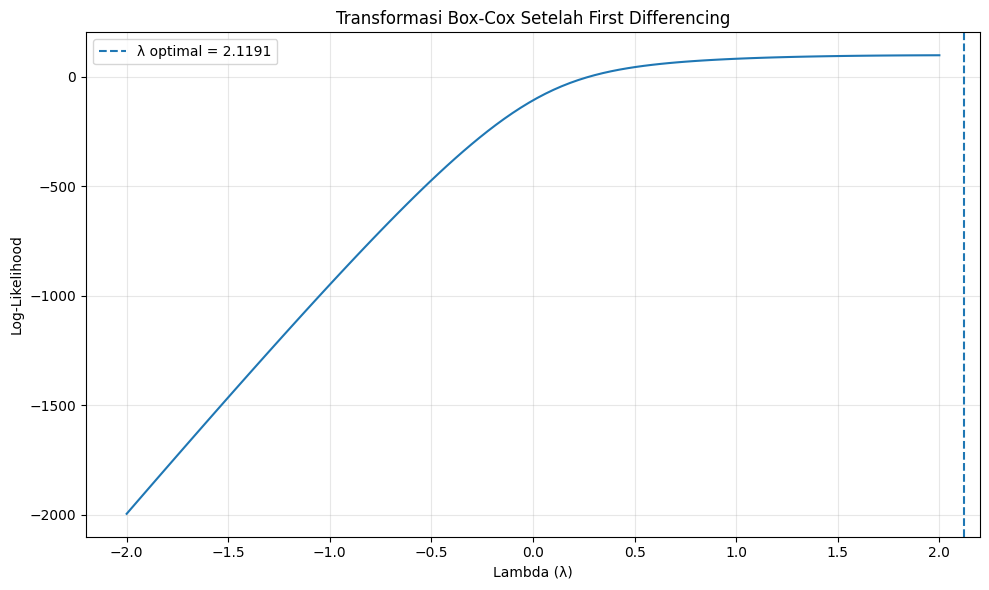

In [ ]:
# ============================================================
# TRANSFORMASI BOX-COX SETELAH FIRST DIFFERENCING
# ============================================================

from scipy.stats import boxcox
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Transformasi Box-Cox
# ------------------------------------------------------------

y_diff_boxcox, lambda_diff = boxcox(y_diff_shift)

print(f"Lambda optimal: {lambda_diff:.4f}")


# ------------------------------------------------------------
# Mencari log-likelihood untuk berbagai nilai lambda
# ------------------------------------------------------------

lambdas = np.linspace(-2, 2, 100)
log_likelihood = []

n = len(y_diff_shift)

for lam in lambdas:

    if lam == 0:
        transformed = np.log(y_diff_shift)
    else:
        transformed = (y_diff_shift**lam - 1) / lam

    variance = np.var(transformed, ddof=1)

    ll = (
        -n / 2 * np.log(variance)
        + (lam - 1) * np.sum(np.log(y_diff_shift))
    )

    log_likelihood.append(ll)


# ------------------------------------------------------------
# Plot Box-Cox
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    lambdas,
    log_likelihood,
    linewidth=1.5
)

plt.axvline(
    lambda_diff,
    linestyle='--',
    label=f'λ optimal = {lambda_diff:.4f}'
)

plt.xlabel('Lambda (λ)')
plt.ylabel('Log-Likelihood')

plt.title(
    'Transformasi Box-Cox Setelah First Differencing'
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Berdasarkan transformasi Box-Cox setelah *first differencing*, diperoleh nilai parameter transformasi optimal sebesar ${\lambda} = 2,1191$. Nilai tersebut merupakan parameter yang memberikan nilai log-likelihood maksimum berdasarkan pendekatan maximum likelihood. Hasil ini menunjukkan bahwa transformasi Box-Cox yang sesuai untuk data hasil *first differencing *yang telah dilakukan shift adalah transformasi dengan parameter ${\lambda}$ lebih besar dari satu. Dengan demikian, data hasil *first differencing* selanjutnya ditransformasikan menggunakan parameter ${\lambda} = 2,1191$. Karena transformasi Box-Cox pada tahap ini dilakukan setelah *first differencing* dan memerlukan penambahan shift untuk mengatasi nilai negatif, hasil parameter ${\lambda}$ perlu diinterpretasikan dengan mempertimbangkan pengaruh shift yang digunakan.

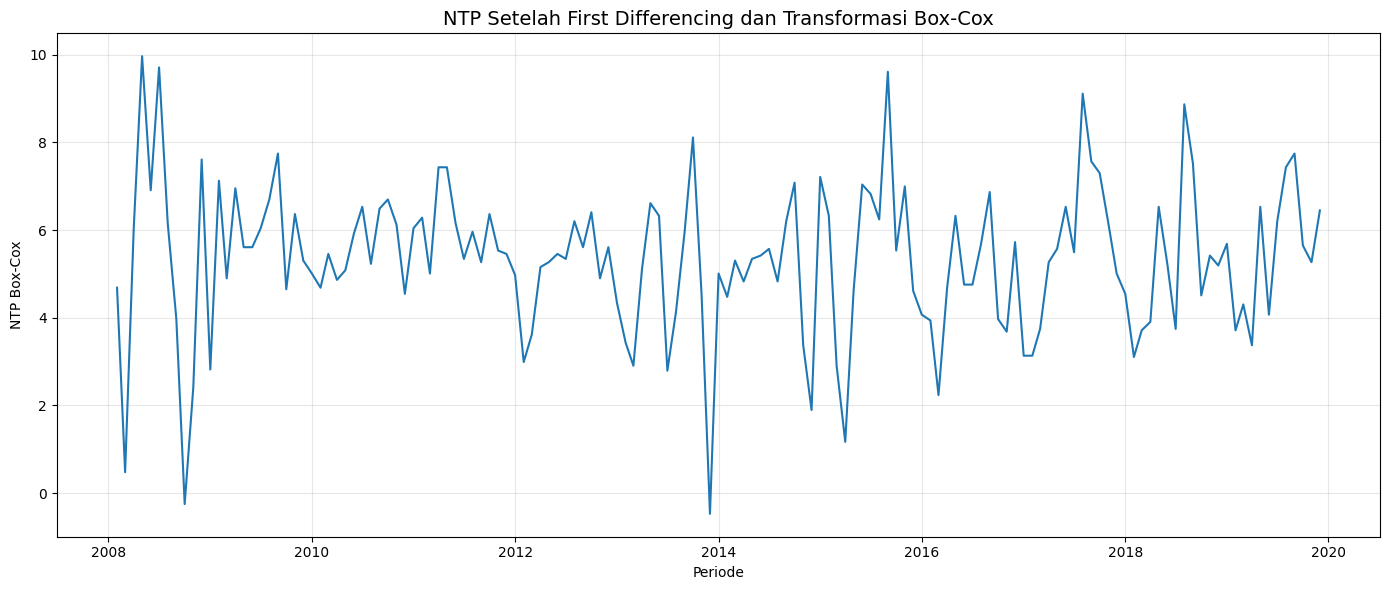

In [ ]:
# ==============================================================
# PLOT DATA SETELAH FIRST DIFFERENCING DAN TRANSFORMASI BOX-COX
# ==============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    df['Periode'].iloc[1:],
    y_diff_boxcox,
    linewidth=1.5
)

plt.title(
    'NTP Setelah First Differencing dan Transformasi Box-Cox',
    fontsize=14
)

plt.xlabel('Periode')
plt.ylabel('NTP Box-Cox')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# UJI ADF SETELAH FIRST DIFFERENCING DAN TRANSFORMASI BOX-COX
# ============================================================

from statsmodels.tsa.stattools import adfuller

adf_final = adfuller(y_diff_boxcox, result_object=False)

print("ADF Statistic :", adf_final[0])
print("p-value       :", adf_final[1])

print("\nCritical Values:")
for key, value in adf_final[4].items():
    print(f"{key}% : {value}")

alpha = 0.05

if adf_final[1] < alpha:
    print("\nKeputusan: Tolak H0")
    print("Kesimpulan: Data sudah stasioner dalam rataan.")
else:
    print("\nKeputusan: Gagal menolak H0")
    print("Kesimpulan: Data belum stasioner dalam rataan.")

ADF Statistic : -7.458607665250483
p-value       : 5.428509172873292e-11

Critical Values:
1%% : -3.479007355368944
5%% : -2.8828782366015093
10%% : -2.5781488587564603

Keputusan: Tolak H0
Kesimpulan: Data sudah stasioner dalam rataan.


Setelah dilakukan transformasi Box-Cox dan differencing orde pertama ($d=1$), selanjutnya dilakukan uji Augmented Dickey-Fuller (ADF) untuk menguji stasioneritas data dalam rataan. Berdasarkan hasil uji ADF diperoleh nilai **ADF Statistic sebesar -7,4586** dengan **p-value sebesar $5,43\times10^{-11}$**. Nilai ADF Statistic tersebut lebih kecil daripada seluruh nilai kritis pada taraf nyata 1%, 5%, dan 10%, yaitu masing-masing sebesar -3,4790, -2,8829, dan -2,5781. Selain itu, p-value yang diperoleh lebih kecil dari taraf nyata 5%, sehingga keputusan yang diambil adalah **menolak $H_0$**.

Dengan demikian, dapat disimpulkan bahwa data hasil transformasi Box-Cox dan differencing orde pertama **telah stasioner dalam rataan**. Namun, uji ADF hanya menguji stasioneritas dalam rataan dan belum dapat memastikan apakah varians data telah konstan. Oleh karena itu, tahap selanjutnya dilakukan **uji ARCH-LM** untuk menguji keberadaan efek ARCH atau ketidakstabilan varians pada data.


In [ ]:
# ===============================================================
# UJI ARCH-LM SETELAH FIRST DIFFERENCING DAN TRANSFORMASI BOX-COX
# ===============================================================

from statsmodels.stats.diagnostic import het_arch
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    arch_final = het_arch(y_diff_boxcox, nlags=12)

print("LM Statistic :", arch_final[0])
print("LM p-value   :", arch_final[1])
print("F Statistic  :", arch_final[2])
print("F p-value    :", arch_final[3])

alpha = 0.05

if arch_final[1] < alpha:
    print("\nKeputusan: Tolak H0")
    print("Kesimpulan: Terdapat efek ARCH pada data.")
else:
    print("\nKeputusan: Gagal menolak H0")
    print("Kesimpulan: Tidak terdapat efek ARCH pada data.")

LM Statistic : 30.613467526687597
LM p-value   : 0.0022556085008944627
F Statistic  : 2.998733229072571
F p-value    : 0.001079280848459432

Keputusan: Tolak H0
Kesimpulan: Terdapat efek ARCH pada data.


Berdasarkan hasil uji ARCH-LM diperoleh nilai **LM Statistic sebesar 30,6135** dengan **p-value sebesar 0,0023**, serta nilai **F Statistic sebesar 2,9987** dengan **p-value sebesar 0,0011**. Pada taraf nyata 5%, kedua p-value tersebut lebih kecil dari 0,05 sehingga keputusan yang diambil adalah **menolak $H_0$**.

Dengan demikian, dapat disimpulkan bahwa **terdapat efek ARCH pada data**, yang menunjukkan adanya ketidakstabilan varians atau **heteroskedastisitas bersyarat** pada residual. Artinya, varians residual pada suatu periode dipengaruhi oleh besar kecilnya kuadrat residual pada periode-periode sebelumnya. Oleh karena itu, meskipun data telah stasioner dalam rataan berdasarkan uji ADF, **varians data belum konstan**, sehingga diperlukan pemodelan volatilitas untuk menangkap dinamika varians tersebut, seperti model **ARCH/GARCH**.


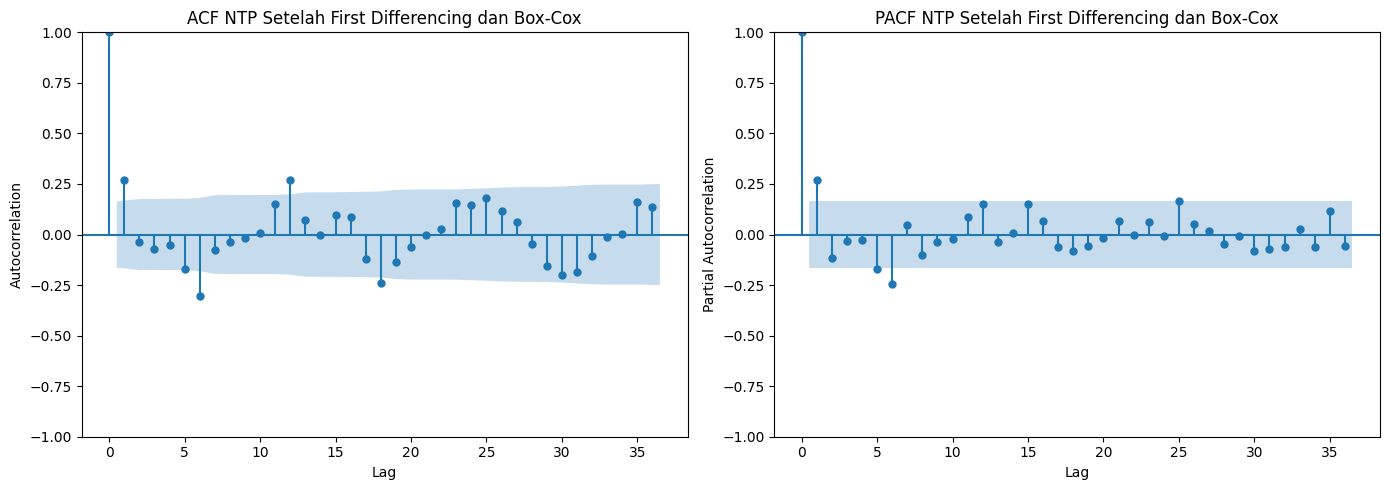

In [ ]:
# =================================================================
# ACF DAN PACF SETELAH FIRST DIFFERENCING DAN TRANSFORMASI BOX-COX
# =================================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Data hasil First Differencing + Box-Cox
# ------------------------------------------------------------

y_final = y_diff_boxcox

# ------------------------------------------------------------
# Membuat ACF dan PACF dalam satu frame
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------
# Plot ACF - sebelah kiri
# ------------------------------------------------------------

plot_acf(
    y_final,
    lags=36,
    alpha=0.05,
    ax=axes[0]
)

axes[0].set_title(
    'ACF NTP Setelah First Differencing dan Box-Cox'
)
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')

# ------------------------------------------------------------
# Plot PACF - sebelah kanan
# ------------------------------------------------------------

plot_pacf(
    y_final,
    lags=36,
    alpha=0.05,
    method='ywm',
    ax=axes[1]
)

axes[1].set_title(
    'PACF NTP Setelah First Differencing dan Box-Cox'
)
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Partial Autocorrelation')

# ------------------------------------------------------------
# Tampilan
# ------------------------------------------------------------

plt.tight_layout()
plt.show()

Berdasarkan plot ACF, terlihat adanya spike yang signifikan pada lag 1. Selain itu, terdapat beberapa spike signifikan pada lag 6, 12, dan 24 yang menunjukkan adanya pola autokorelasi dan kemungkinan pola musiman.

Pada plot PACF, terdapat spike yang signifikan pada lag 1 dan lag 6, serta beberapa spike pada lag 12 dan 15. Berdasarkan pola ACF dan PACF tersebut, dapat dipertimbangkan beberapa kandidat model SARIMA dengan periode musiman s = 12. Orde AR dan MA selanjutnya ditentukan dengan membandingkan beberapa kandidat model berdasarkan nilai AIC/BIC dan hasil uji diagnostik residual.

# **KESIMPULAN**  

Berdasarkan dua skenario penanganan ketidakstasioneran data yang dilakukan, yaitu transformasi Box-Cox → Differencing dan differencing → transformasi Box-Cox diperoleh bahwa kedua skenario menghasilkan data yang stasioner berdasarkan uji ADF. Namun, hasil uji ARCH-LM menunjukkan perbedaan, yaitu pada skenario transformasi Box-Cox → differencing tidak ditemukan bukti adanya efek ARCH, sedangkan pada skenario differencing → transformasi Box-Cox masih ditemukan efek ARCH. Berdasarkan hasil tersebut, skenario **transformasi Box-Cox → differencing** digunakan untuk tahap analisis selanjutnya.